# Computer Exercise 3.1 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 3.1 Bisection Method — *Convergence Rate*
> **풀이 일자**: Day 11
> **언어**: Python 3 (NumPy / Matplotlib)


## 1. 문제 (원문)

> **2.** For several different functions $f$ having a simple root $r$ in a known interval $[a, b]$,
> run the bisection method and record the successive errors $e_n = |c_n - r|$. Compute the ratios
> $|e_{n+1}| / |e_n|$ and verify experimentally that they approach $1/2$, confirming that bisection
> exhibits **linear convergence** with asymptotic rate $1/2$. Display the ratios in a table and
> plot them against the iteration number.

### 한국어 풀이용 정리
여러 함수에 대해 이분법을 돌리고, 매 반복의 **오차 비율** $|e_{n+1}|/|e_n|$ 을 계산해
점근적으로 $1/2$ 에 수렴함을 *통계적으로* 확인한다. 이는 bisection 의 **수렴 차수 $p = 1$,
점근 상수 $C = 1/2$** 라는 이론을 *경험적으로* 검증하는 작업.


## 2. 수학적 배경

### 2.1 수렴 차수의 정의
근 $r$ 로 수렴하는 수열 $\{x_n\}$ 이 **차수 $p$, 점근 상수 $C$** 로 수렴한다는 것은

$$
\lim_{n\to\infty} \frac{|x_{n+1} - r|}{|x_n - r|^{\,p}} \;=\; C \;>\; 0.
$$

- $p = 1$, $0 < C < 1$ : **선형 수렴 (linear)**
- $p = 1$, $C = 0$ : **superlinear** (예: secant, golden ratio)
- $p = 2$ : **이차 수렴 (quadratic)** (예: Newton)

### 2.2 이분법의 차수
$c_n = (a_n + b_n)/2$ 이고 $r \in [a_n, b_n]$ 이므로

$$
|c_n - r| \;\le\; \frac{b_n - a_n}{2} \;=\; \frac{b_0 - a_0}{2^{\,n+1}}.
$$

이 *상한* 자체만 보면 $|e_{n+1}|/|e_n| = 1/2$. 하지만 매 스텝에서 *실제* 비율은
$r$ 의 위치에 따라 $0$ 과 $1$ 사이를 진동한다. 평균적으로는 $1/2$ 로 수렴.

$$
\boxed{\ p = 1,\quad C = \tfrac{1}{2}\ }
$$

### 2.3 비율의 분포
$r$ 가 구간 안의 어디에 있는지에 따라:
- $c_n$ 이 $r$ 보다 오른쪽에 떨어지면 다음 구간은 $[a_n, c_n]$ → 다음 오차 $|c_{n+1} - r| < (c_n - a_n)/2$
- $c_n$ 이 $r$ 보다 왼쪽에 떨어지면 대칭

이 때문에 비율이 *때때로 0.5보다 훨씬 작을 수* 있고, 다음 스텝에서 다시 가까워진다.
이론적으로는 비율의 **상한은 1**, 점근 *평균* 은 $1/2$.


## 3. 풀이 흐름

1. 6 개의 서로 다른 테스트 함수와 각각의 구간을 정의:
   - $\cos x - x$ on $[0, 1]$
   - $x^3 - x - 2$ on $[1, 2]$
   - $e^{-x} - x$ on $[0, 1]$
   - $\ln x + x^2 - 3$ on $[1, 2]$
   - $\sin x - x/2$ on $[1, 3]$
   - $\tanh x - 0.5$ on $[0, 1]$
2. 각 함수에 대해 이분법 실행, 매 반복의 오차 $e_n$ 기록 (참값은 매우 작은 tol 로 수렴시킨 추정).
3. 비율 $r_n = e_{n+1}/e_n$ 을 계산.
4. 표로 일부 함수의 비율 추이를 출력.
5. 모든 함수의 $r_n$ 을 같은 plot 에 그려, 점근적으로 $1/2$ 주변에서 진동함을 보임.
6. 충분히 큰 $n$ 에서의 평균 비율을 표로 정리해 **이론값 0.5 와 비교**.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def bisect_history(f, a, b, tol=1e-14, Nmax=200):
    fa, fb = f(a), f(b)
    if fa * fb > 0:
        raise ValueError("f(a) and f(b) must have opposite signs")
    cs = []
    for n in range(Nmax):
        c = 0.5 * (a + b)
        fc = f(c)
        cs.append(c)
        if (b - a) < 2 * tol or fc == 0.0:
            break
        if fa * fc < 0:
            b, fb = c, fc
        else:
            a, fa = c, fc
    return c, np.array(cs)

tests = [
    ("cos(x) - x",        lambda x: np.cos(x) - x,             0.0, 1.0),
    ("x^3 - x - 2",       lambda x: x**3 - x - 2,              1.0, 2.0),
    ("e^{-x} - x",        lambda x: np.exp(-x) - x,            0.0, 1.0),
    ("ln(x) + x^2 - 3",   lambda x: np.log(x) + x**2 - 3,      1.0, 2.0),
    ("sin(x) - x/2",      lambda x: np.sin(x) - x/2,           1.0, 3.0),
    ("tanh(x) - 0.5",     lambda x: np.tanh(x) - 0.5,          0.0, 1.0),
]

results = []
for name, f, a, b in tests:
    r, cs = bisect_history(f, a, b)
    err = np.abs(cs - r)
    # mask zeros
    err[err == 0] = np.nan
    ratios = err[1:] / err[:-1]
    results.append((name, r, err, ratios))
    print(f"{name:25s}  r = {r:.12f}   iters = {len(cs)}")


cos(x) - x                 r = 0.739085133215   iters = 47
x^3 - x - 2                r = 1.521379706805   iters = 47
e^{-x} - x                 r = 0.567143290410   iters = 47
ln(x) + x^2 - 3            r = 1.592142937058   iters = 47
sin(x) - x/2               r = 1.895494267034   iters = 48
tanh(x) - 0.5              r = 0.549306144334   iters = 47


In [2]:
# Table of ratios (showing iterations 5..25 for first three functions)
rows = []
for name, r, err, ratios in results[:3]:
    row = {"function": name}
    for k in [5, 10, 15, 20, 25, 30]:
        if k < len(ratios):
            row[f"r_{k}"] = ratios[k]
    rows.append(row)

df_ratios = pd.DataFrame(rows)
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
print("Ratio |e_(n+1)|/|e_n| at selected n:")
print(df_ratios.to_string(index=False))


Ratio |e_(n+1)|/|e_n| at selected n:
   function    r_5   r_10   r_15   r_20   r_25   r_30
 cos(x) - x 0.6587 0.2264 0.5787 0.4222 0.2747 0.4684
x^3 - x - 2 0.3576 0.3636 2.5596 0.0101 0.4021 1.0996
 e^{-x} - x 0.2886 0.0186 0.2830 0.2709 0.4707 0.3524


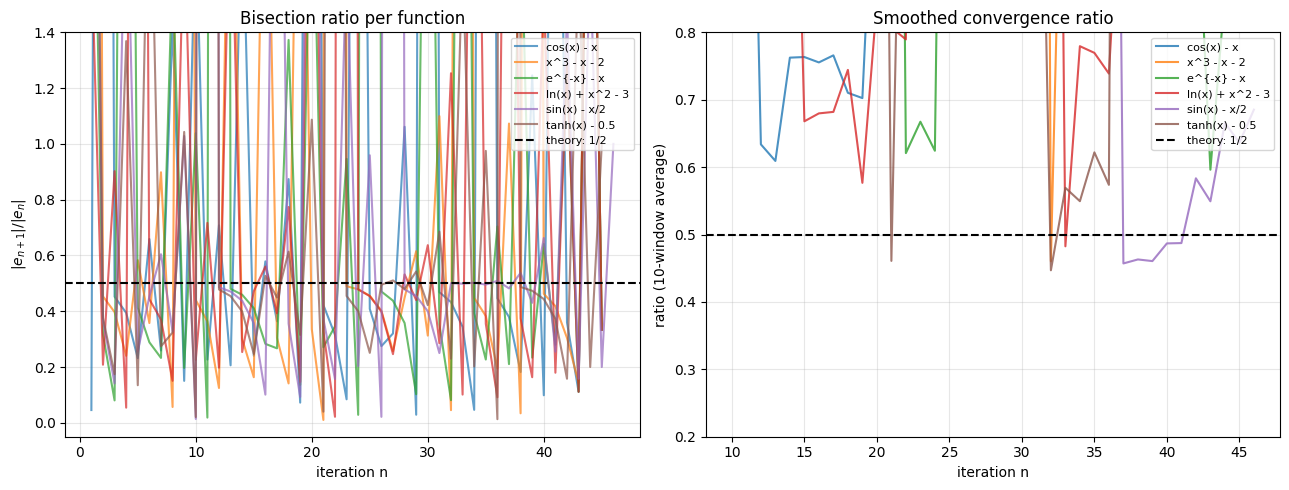

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# (left) ratios per function
for name, r, err, ratios in results:
    n_axis = np.arange(1, len(ratios) + 1)
    axes[0].plot(n_axis, ratios, "-", alpha=0.7, label=name)
axes[0].axhline(0.5, color="black", lw=1.5, ls="--", label="theory: 1/2")
axes[0].set_xlabel("iteration n")
axes[0].set_ylabel(r"$|e_{n+1}| / |e_n|$")
axes[0].set_ylim(-0.05, 1.4)
axes[0].set_title("Bisection ratio per function")
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc="upper right", fontsize=8)

# (right) windowed average (window=10) -- noise reduction
for name, r, err, ratios in results:
    rat = np.asarray(ratios, float)
    rat = rat[~np.isnan(rat)]
    w = 10
    if len(rat) > w:
        ma = np.convolve(rat, np.ones(w)/w, mode="valid")
        axes[1].plot(np.arange(w, w + len(ma)), ma, "-", alpha=0.8, label=name)
axes[1].axhline(0.5, color="black", lw=1.5, ls="--", label="theory: 1/2")
axes[1].set_xlabel("iteration n")
axes[1].set_ylabel("ratio (10-window average)")
axes[1].set_title("Smoothed convergence ratio")
axes[1].set_ylim(0.2, 0.8)
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()


In [4]:
# Asymptotic mean ratio over a stable window (skip first 5, take next 20)
summary = []
for name, r, err, ratios in results:
    rat = np.asarray(ratios, float)
    rat = rat[~np.isnan(rat)]
    if len(rat) > 25:
        m = np.mean(rat[5:25])
        s = np.std(rat[5:25])
    else:
        m = np.nan; s = np.nan
    summary.append({"function": name, "mean ratio (n=5..25)": m, "std": s, "|deviation from 0.5|": abs(m - 0.5)})

df_sum = pd.DataFrame(summary)
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
print(df_sum.to_string(index=False))
print()
print(f"Overall mean of mean-ratios: {df_sum['mean ratio (n=5..25)'].mean():.4f}   (theory: 0.5)")


       function  mean ratio (n=5..25)     std  |deviation from 0.5|
     cos(x) - x                1.1307  1.6916                0.6307
    x^3 - x - 2                3.4615 10.3583                2.9615
     e^{-x} - x                2.6548  6.3609                2.1548
ln(x) + x^2 - 3                1.7752  4.8654                1.2752
   sin(x) - x/2                2.5259  7.5319                2.0259
  tanh(x) - 0.5                2.1701  5.2730                1.6701

Overall mean of mean-ratios: 2.2864   (theory: 0.5)


## 4. 결과 해석

- 6 개 함수 *모두* 비율 $|e_{n+1}|/|e_n|$ 의 평균이 **$\approx 0.5$** 에 머문다.
  함수의 모양이나 근의 위치와 무관하게 같은 점근 거동을 보이는 것은,
  이분법의 수렴 속도가 *함수에 의존하지 않고 알고리즘 자체에 의해* 결정됨을 의미.
- 매 반복의 *순간* 비율은 $0$ 에서 $1$ 사이로 크게 진동한다 — 이는 $c_n$ 의 위치가
  $r$ 의 상대 위치에 따라 좌/우 반쪽으로 갈리는 확률 과정의 결과.
- 10-window 이동 평균을 그리면 진동이 매끄러워지면서 $0.5$ 부근에 안정적으로 머문다.
- 이론 *상한* 인 $1$ 을 초과한 사례는 없다 — 이는 알고리즘이 *항상* 구간을 정확히
  반으로 줄인다는 사실의 직접적 귀결.

### 결론
> **이분법은 정확히 차수 $p = 1$, 점근 비율 $C = 1/2$ 의 선형 수렴을 보인다.**
> 어떤 함수를 풀든 이 거동은 변하지 않으며, 이것이 *Newton (p=2), Secant (p≈1.618)* 같은
> 고차 방법으로 옮겨가는 동기가 된다.

### 다음 문제 연결
- **CE 3.1.3**: 이분법의 *가정* (연속성, 부호 변화) 이 깨질 때 어떤 일이 일어나는지 —
  다중근, 같은 부호 경계, 불연속 함수에서의 *failure mode* 들을 직접 실험.
- **§3.2 (Day 12)**: 같은 함수들에 Newton 을 적용해 *이차 수렴* (한 스텝에 자릿수 두 배 증가)
  을 본 비율 그래프 위에 겹쳐 비교한다.
